# P0 · Build a vocabulary

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys
print("Python", sys.version.split()[0])
print("Self-contained notebook. Run top to bottom; no repository clone or API key.")


Python 3.12.3
Self-contained notebook. Run top to bottom; no repository clone or API key.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P0.4 · Build a vocabulary

A vocabulary gives each known character one ID. A reverse mapping reconstructs the text from those IDs.

**Prerequisites:** Containers and shared references

**Predict:** What changes when a known character repeats?

**Mental model:** The model performs calculations on numbers, but text begins as characters. A vocabulary provides a reversible naming system between those representations.

### Why this operation exists

The model performs calculations on numbers, but text begins as characters. A vocabulary provides a reversible naming system between those representations.

An ID names a character; a larger ID does not mean a more important character. The learned embedding supplies the vector used for calculation later.

A set removes repeated characters, and sorting makes the order of this illustrative vocabulary explicit. Enumerating assigns an index in that order.

Repeating a letter in the text should repeat its ID, not create a new vocabulary entry. Predict what changes when the final letter appears twice.

Keep the vocabulary with the model. Changing the mapping while keeping learned weights would give old vectors new meanings.

### Follow the values

Start with t, o, a space, b and e. The text has five positions, each of which will receive an ID.

The sorted vocabulary contains a space, b, e, o and t. Repeated occurrences would still contribute only one entry to this set.

Enumerating those entries creates IDs zero through four. The dictionary pairs each character with its lookup result.

Look up the original positions in order. The encoded text is 4, 3, 0, 1, 2. In the second experiment the extra e adds another 2.

Index the vocabulary by each ID and join the characters. The round trip must return the exact source, including whitespace.

In [3]:
FRAMES.clear()
change = 0
text = "to be" if not change else "to bee"
show("Text positions", list(text))
chars = sorted(set(text))
show("Sorted unique characters", chars)
stoi = {ch: i for i, ch in enumerate(chars)}
show("Character to ID", stoi)
ids = [stoi[ch] for ch in text]
show("Encoded positions", ids)
decoded = "".join(chars[i] for i in ids)
show("Decoded text", decoded)
assert decoded == text

Text positions: ["t", "o", " ", "b", "e"]
Sorted unique characters: [" ", "b", "e", "o", "t"]
Character to ID: {" ": 0, "b": 1, "e": 2, "o": 3, "t": 4}
Encoded positions: [4, 3, 0, 1, 2]
Decoded text: "to be"


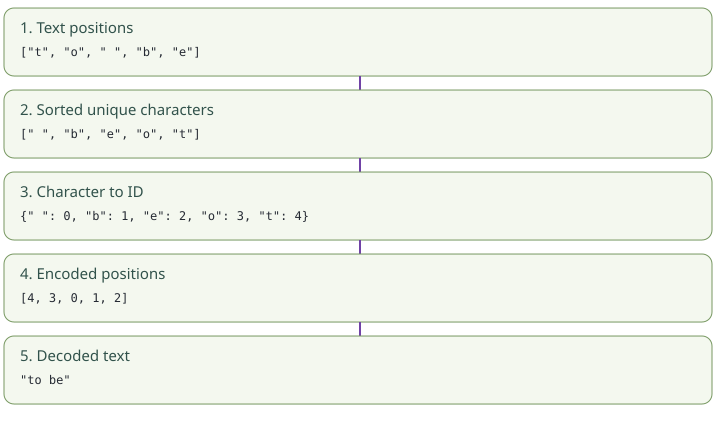

In [4]:
draw_trace()

### Read the implementation

Set collects unique characters; sorted returns them in a deterministic order for this example. Do not rely on the iteration order of a set for a saved vocabulary.

Enumerate produces pairs containing a position and a character. The dictionary comprehension uses those pairs to build the forward mapping.

The list comprehension performs one dictionary lookup per source character. A missing character raises a KeyError in this closed-vocabulary example.

The reverse direction uses the vocabulary list itself: its position is the ID. Join combines the recovered characters without inserting extra spaces.

Assert the round trip, and separately check an unknown character. Choosing an unknown-token policy belongs to the tokenizer design, not an accidental exception handler.

### Change one thing

**Repeat the final e**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [5]:
FRAMES.clear()
change = 1
text = "to be" if not change else "to bee"
show("Text positions", list(text))
chars = sorted(set(text))
show("Sorted unique characters", chars)
stoi = {ch: i for i, ch in enumerate(chars)}
show("Character to ID", stoi)
ids = [stoi[ch] for ch in text]
show("Encoded positions", ids)
decoded = "".join(chars[i] for i in ids)
show("Decoded text", decoded)
assert decoded == text

Text positions: ["t", "o", " ", "b", "e", "e"]
Sorted unique characters: [" ", "b", "e", "o", "t"]
Character to ID: {" ": 0, "b": 1, "e": 2, "o": 3, "t": 4}
Encoded positions: [4, 3, 0, 1, 2, 2]
Decoded text: "to bee"


### A useful distinction

The numerical distance between two token IDs does not describe similarity between their meanings.

### ✋ Your turn

Build a sorted vocabulary for "aba ", encode it, and put the ID list in answer.

In [6]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [1, 2, 1, 0], 'The numerical distance between two token IDs does not describe similarity between their meanings.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [7]:
#@title Show a solution { display-mode: "form" }
chars = sorted(set("aba "))
stoi = {ch: i for i, ch in enumerate(chars)}
answer = [stoi[ch] for ch in "aba "]

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [1, 2, 1, 0], 'The numerical distance between two token IDs does not describe similarity between their meanings.'
    print("✓ right:", answer)

✓ right: [1, 2, 1, 0]


### Reconnect to the transformer

The current model constructs a character tokenizer with a sorted vocabulary and a character-to-ID mapping. Its complete dataset supplies more characters than this tiny illustration.

The model's token embedding table has one entry for each vocabulary ID. The same mapping must be used when preparing data and decoding generated IDs.

Phyll uses a larger tokenizer with special IDs and multi-character pieces. The vocabulary contract transfers, while the segmentation algorithm changes.

Save the tokenizer configuration beside the weights. A matching vocabulary size alone does not prove a matching ID-to-text mapping.

Next, expand the compact comprehensions and trace how iteration produces each output.

```python
self.chars = sorted(set(text))
self.stoi = {ch: i for i, ch in enumerate(self.chars)}
return [self.stoi[ch] for ch in text]
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** What changes when a known character repeats?

<details><summary>Check your explanation</summary>

The ID sequence grows. The numerical distance between two token IDs does not describe similarity between their meanings.

</details>